In [31]:
import subprocess
import time

# Start MLflow server in background if not already running
mlflow_server = subprocess.Popen(
    ["uv", "run", "mlflow", "ui", "--port", "5000"],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)

time.sleep(3)  # Give it time to start up
print("✅ MLflow server started at http://localhost:5000")

✅ MLflow server started at http://localhost:5000


In [32]:
import duckdb
import pandas as pd
import numpy as np
import mlflow
import mlflow.sklearn
import mlflow.xgboost
import shap
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (classification_report, roc_auc_score, 
                              confusion_matrix, PrecisionRecallDisplay,
                              precision_recall_curve, average_precision_score)
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

# Point MLflow at your local server
mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("olist-customer-value-scoring")

print("✅ Setup complete")

✅ Setup complete


In [33]:
con = duckdb.connect('../data/olist.db')
print(f"Connected ✅")
print(con.execute("SHOW TABLES").df().to_string())

Connected ✅
                    name
0   category_translation
1              customers
2            geolocation
3            order_items
4          order_payment
5         order_payments
6          order_reviews
7                 orders
8                product
9               products
10               sellers


In [34]:
query = """
WITH
  base_orders AS (
    SELECT
      customers.customer_unique_id,
      orders.order_id,
      orders.order_purchase_timestamp,
      ROW_NUMBER() OVER (
        PARTITION BY
          customer_unique_id
        ORDER BY
          orders.order_purchase_timestamp
      ) as order_rank
    FROM
      orders
      LEFT JOIN customers ON orders.customer_id = customers.customer_id
    WHERE
      orders.order_status = 'delivered'
  ),
  first_orders AS (
    SELECT
      *
    FROM
      base_orders
    WHERE
      order_rank = 1
  ),
  customer_total_spend AS (
  	SELECT
  		customers.customer_unique_id,
  		SUM(order_items.price + order_items.freight_value) AS total_spend
  	FROM orders
  	LEFT JOIN customers ON orders.customer_id = customers.customer_id
  	LEFT JOIN order_items ON orders.order_id = order_items.order_id
  	WHERE orders.order_status = 'delivered'
  	GROUP BY customers.customer_unique_id
  ),
  first_order_features AS (
    SELECT
      first_orders.customer_unique_id,
      first_orders.order_purchase_timestamp,
      SUM(oi.price + oi.freight_value) AS first_order_value,
      COUNT(DISTINCT oi.product_id) AS unique_products_in_first_order,
      AVG(oi.freight_value / (oi.freight_value + oi.price)) AS first_freight_ratio,
      MAX(r.review_score) AS first_review_score,
      MAX(p.payment_installments) AS first_payment_installments,
      DAYOFWEEK (first_orders.order_purchase_timestamp) AS first_purchase_dayofweek,
      DATEDIFF (
        'day',
        MAX(o.order_delivered_customer_date),
        MAX(o.order_estimated_delivery_date)
      ) AS first_delivery_delay_days
    FROM
      first_orders
      LEFT JOIN order_items oi ON first_orders.order_id = oi.order_id
      LEFT JOIN order_reviews r ON first_orders.order_id = r.order_id
      LEFT JOIN order_payments p ON first_orders.order_id = p.order_id
      LEFT JOIN orders o ON first_orders.order_id = o.order_id
    GROUP BY
      first_orders.customer_unique_id,
      first_orders.order_purchase_timestamp,
      first_orders.order_id
  )
SELECT
  fts.customer_unique_id,
  fts.order_purchase_timestamp,
  fts.first_order_value,
  fts.unique_products_in_first_order,
  fts.first_freight_ratio,
  fts.first_review_score,
  fts.first_payment_installments,
  fts.first_purchase_dayofweek,
  fts.first_delivery_delay_days,
  total_spend,
  CASE WHEN total_spend > 182.51 THEN 1 ELSE 0 END AS high_value
FROM
  first_order_features fts
LEFT JOIN customer_total_spend cts on fts.customer_unique_id = cts.customer_unique_id
"""

df = con.execute(query).df()

print(f"Data shape: {df.shape}")
print(f"High value cistomers: {df['high_value'].sum():,}")
print(f"High value rate: {df['high_value'].mean():.2%}")
print("\nMissing values:")
print(df.isnull().sum())
print("\nFeature summary:")
df.describe().round(2)
# df.head(5)

Data shape: (93358, 11)
High value cistomers: 23,340
High value rate: 25.00%

Missing values:
customer_unique_id                  0
order_purchase_timestamp            0
first_order_value                   0
unique_products_in_first_order      0
first_freight_ratio                 0
first_review_score                617
first_payment_installments          1
first_purchase_dayofweek            0
first_delivery_delay_days           8
total_spend                         0
high_value                          0
dtype: int64

Feature summary:


,order_purchase_timestamp,first_order_value,unique_products_in_first_order,first_freight_ratio,first_review_score,first_payment_installments,first_purchase_dayofweek,first_delivery_delay_days,total_spend,high_value
count,93358,93358.00,93358.00,93358.00,92741.0,93357.0,93358.00,93350.0,93358.00,93358.00
mean,2018-01-01 12:18:32.380503,167.90,1.04,0.21,4.15,2.92,2.91,11.85,165.17,0.25
min,2016-09-15 12:16:38,10.07,1.00,0.00,1.0,0.0,0.00,-188.0,9.59,0.00
25%,2017-09-13 15:41:22.500000,63.04,1.00,0.12,4.0,1.0,1.00,7.0,63.01,0.00
50%,2018-01-20 06:48:07,107.78,1.00,0.18,5.0,2.0,3.00,12.0,107.78,0.00
75%,2018-05-05 14:13:38.250000,182.34,1.00,0.28,5.0,4.0,5.00,17.0,182.51,0.75
max,2018-08-29 15:00:37,13664.08,8.00,0.96,5.0,24.0,6.00,147.0,13664.08,1.00
std,NaN,252.29,0.22,0.13,1.28,2.7,1.89,10.19,226.29,0.43


In [35]:
# In this cell we are doing some pre-processing. 

# 1. Droping the customer_unique_id, first_order_date, last_order_date
df = df.drop(columns=['customer_unique_id', 'order_purchase_timestamp', 'total_spend'])

# 2. dropping the missing 
df = df[~df['first_payment_installments'].isnull()]
df = df[~df['first_review_score'].isnull()]
df = df[~df['first_delivery_delay_days'].isnull()]

# Convert nullable integer columns to standard numpy types
nullable_int_cols = ['first_review_score', 'first_payment_installments', 'first_delivery_delay_days']
for col in nullable_int_cols:
    df[col] = df[col].astype('float64')

# 3. Defining Feature cols
feature_cols = df.columns.drop('high_value')
X = df[feature_cols]
y = df['high_value']

# 4. Train / Test Split - stratified, 80/20, random_state = 42
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5. Smote for training data only
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print(f"Training data shape BEFORE the SMOTE: {X_train.shape}")
print(f"Training data shape AFTER the SMOTE: {X_train_bal.shape}")

Training data shape BEFORE the SMOTE: (74185, 7)
Training data shape AFTER the SMOTE: (111346, 7)


In [36]:
# Training the Random Forest Algorithm

rf_params = {
    "n_estimators": 300,
    "max_depth": 8,
    "min_samples_leaf": 20,
    "class_weight": "balanced",
    "random_state": 42,
    "n_jobs": -1,
}

with mlflow.start_run(run_name="RandomForest_v1"):

    # 1. Train
    rf_model = RandomForestClassifier(**rf_params)
    rf_model.fit(X_train_bal, y_train_bal)

    # 2. Predict
    y_pred = rf_model.predict(X_test)
    y_proba = rf_model.predict_proba(X_test)[:, 1]

    # 3. Score
    roc_auc = roc_auc_score(y_test, y_proba)

    # 4. Log to MLflow
    mlflow.log_params(rf_params)
    mlflow.log_metric("roc_auc", roc_auc)
    mlflow.sklearn.log_model(rf_model, "random_forest_model")

    print(f"ROC-AUC-RF: {roc_auc:.4f}")
    print(classification_report(y_test, y_pred))

2026/05/18 14:11:22 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/18 14:11:22 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/18 14:11:25 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


ROC-AUC-RF: 0.9816
              precision    recall  f1-score   support

           0       0.99      0.98      0.98     13919
           1       0.95      0.96      0.95      4628

    accuracy                           0.98     18547
   macro avg       0.97      0.97      0.97     18547
weighted avg       0.98      0.98      0.98     18547

🏃 View run RandomForest_v1 at: http://localhost:5000/#/experiments/3/runs/08ec520a8cd140eab92ea00955451cec
🧪 View experiment at: http://localhost:5000/#/experiments/3


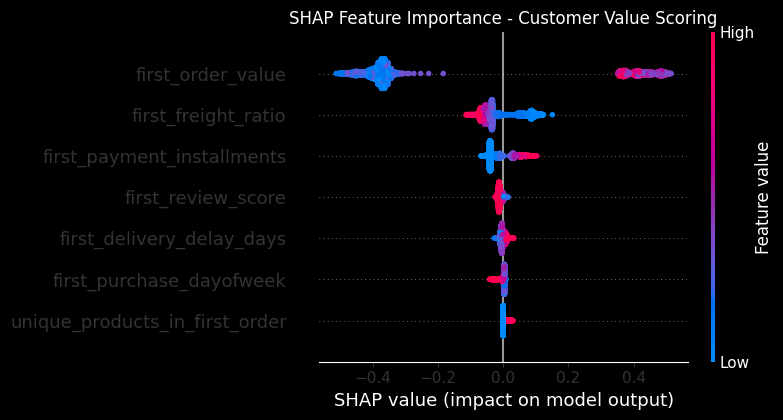

In [40]:
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values[:,:,1], X_test, show=False)
plt.title("SHAP Feature Importance - Customer Value Scoring")
plt.tight_layout()
plt.savefig('../reports/figures/shap_customer_value.png', dpi=150, bbox_inches='tight')
plt.show()